# 1.1. Hồi quy Tuyến tính (Linear Regression)

> **Mục tiêu**: Cài đặt từ đầu các phương pháp hồi quy tuyến tính, bao gồm Normal Equations, Mini-batch Gradient Descent, kiểm tra giả thiết Gauss–Markov, và Weighted Least Squares.

## 0. Import thư viện và load dữ liệu

In [1]:
import sys, os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", font_scale=1.1, rc={
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Reproducibility
SEED = 42
np.random.seed(SEED)

# --- Thêm project root vào path để load data ---
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from data.load_data import load_regression_data

data = load_regression_data()
X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]
feature_names = data["feature_names"]
weights_train = data["weights_train"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")
print(f"Features: {feature_names}")

X_train: (12165, 49), y_train: (12165,)
X_val  : (1737, 49),   y_val  : (1737,)
X_test : (3477, 49),  y_test : (3477,)
Features: ['temp', 'hum', 'windspeed', 'season_2', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'time_of_day_1', 'time_of_day_2', 'yr', 'workingday', 'holiday', 'is_rush_hour']


## 0.1. Hàm phụ trợ: thêm cột bias và các chỉ số đánh giá

Mọi mô hình tuyến tính đều cần **cột bias** (cột toàn 1) để biểu diễn hệ số chặn $w_0$.

Các chỉ số đánh giá được implement từ đầu (không dùng `sklearn`):
- **MSE** = $\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$
- **RMSE** = $\sqrt{\text{MSE}}$
- **MAE** = $\frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$
- **R²** = $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$

In [2]:
def _add_bias(X):
    """Thêm cột bias (cột 1) vào đầu ma trận X."""
    return np.column_stack([np.ones(X.shape[0]), X])

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot != 0 else 0.0

def compute_all_metrics(y_true, y_pred):
    return {"MSE": mse(y_true, y_pred), "RMSE": rmse(y_true, y_pred),
            "MAE": mae(y_true, y_pred), "R²": r_squared(y_true, y_pred)}

def print_metrics(metrics, model_name="Model"):
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    for name, value in metrics.items():
        print(f"  {name:>6s}: {value:.6f}")
    print(f"{'='*50}\n")

---
## 1. Normal Equations (Nghiệm dạng đóng)

### 1.1. Cơ sở lý thuyết

Cho tập dữ liệu $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$ với $\mathbf{x}_i \in \mathbb{R}^D$, mô hình hồi quy tuyến tính có dạng:

$$\hat{y} = \mathbf{X} \mathbf{w}$$

trong đó $\mathbf{X} \in \mathbb{R}^{N \times (D+1)}$ là ma trận thiết kế (design matrix) đã thêm cột bias, $\mathbf{w} \in \mathbb{R}^{D+1}$ là vector trọng số.

**Hàm mất mát** (loss function) — trung bình bình phương sai số:

$$\mathcal{L}(\mathbf{w}) = \frac{1}{N} \| \mathbf{y} - \mathbf{X}\mathbf{w} \|^2 = \frac{1}{N} (\mathbf{y} - \mathbf{X}\mathbf{w})^T (\mathbf{y} - \mathbf{X}\mathbf{w})$$

Lấy đạo hàm theo $\mathbf{w}$ và cho bằng 0:

$$\nabla_\mathbf{w} \mathcal{L} = -\frac{2}{N} \mathbf{X}^T (\mathbf{y} - \mathbf{X}\mathbf{w}) = 0$$

$$\Rightarrow \mathbf{X}^T \mathbf{X} \mathbf{w} = \mathbf{X}^T \mathbf{y}$$

$$\boxed{\mathbf{w}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}}$$

Đây là **Normal Equations**. Nghiệm tồn tại duy nhất khi $\mathbf{X}^T\mathbf{X}$ khả nghịch.

> **Ghi chú**: Thay vì tính nghịch đảo trực tiếp (không ổn định số học), ta dùng `np.linalg.solve` để giải hệ phương trình tuyến tính $\mathbf{X}^T\mathbf{X} \cdot \mathbf{w} = \mathbf{X}^T\mathbf{y}$.

### 1.2. Cài đặt class `NormalEquationLR`

In [3]:
class NormalEquationLR:
    """Linear Regression via Normal Equations (closed-form).
    
    Giải w = (X^T X)^{-1} X^T y, trong đó X đã thêm cột bias.
    KHÔNG sử dụng sklearn.LinearRegression.
    """
    
    def __init__(self):
        self.w = None
        self.fit_time = 0.0
    
    def fit(self, X, y, **kwargs):
        t0 = time.perf_counter()
        X_b = _add_bias(X)
        # Normal Equations: w = (X^T X)^{-1} X^T y
        XtX = X_b.T @ X_b
        Xty = X_b.T @ y
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        X_b = _add_bias(X)
        return X_b @ self.w
    
    @property
    def coefficients(self):
        return self.w[1:] if self.w is not None else np.array([])
    
    @property
    def intercept(self):
        return float(self.w[0]) if self.w is not None else 0.0

### 1.3. Huấn luyện và đánh giá

In [4]:
# Huấn luyện
ne_model = NormalEquationLR()
ne_model.fit(X_train, y_train)

print(f"Thời gian huấn luyện: {ne_model.fit_time:.6f} giây")
print(f"Intercept (w0): {ne_model.intercept:.6f}")
print(f"Số hệ số: {len(ne_model.coefficients)}")

# Đánh giá trên tập test
y_pred_ne = ne_model.predict(X_test)
metrics_ne = compute_all_metrics(y_test, y_pred_ne)
print_metrics(metrics_ne, "Normal Equations — Test Set")

# Đánh giá trên tập train (kiểm tra overfit)
y_pred_ne_train = ne_model.predict(X_train)
metrics_ne_train = compute_all_metrics(y_train, y_pred_ne_train)
print_metrics(metrics_ne_train, "Normal Equations — Train Set")

Thời gian huấn luyện: 0.020583 giây
Intercept (w0): 3.526577
Số hệ số: 49

  Normal Equations — Test Set
     MSE: 0.349341
    RMSE: 0.591051
     MAE: 0.447499
      R²: 0.825117


  Normal Equations — Train Set
     MSE: 0.366941
    RMSE: 0.605756
     MAE: 0.457295
      R²: 0.817694



---
## 2. Mini-batch Gradient Descent

### 2.1. Cơ sở lý thuyết

Thay vì giải trực tiếp Normal Equations, ta có thể tối ưu hàm mất mát bằng **Gradient Descent**:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \cdot \nabla_\mathbf{w} \mathcal{L}$$

**Gradient** của MSE trên một mini-batch $\mathcal{B}$ kích thước $m$:

$$\nabla_\mathbf{w} \mathcal{L}_{\mathcal{B}} = \frac{1}{m} \mathbf{X}_{\mathcal{B}}^T (\mathbf{X}_{\mathcal{B}} \mathbf{w} - \mathbf{y}_{\mathcal{B}})$$

### Learning Rate Schedules

1. **Step Decay**: Giảm learning rate theo bước cố định
$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t / s \rfloor}$$
   - $\gamma$: decay rate, $s$: decay steps

2. **Cosine Annealing**: Learning rate theo hàm cosine
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\frac{\pi t}{T}\right)$$
   - $T$: tổng số epochs

> **Ưu điểm của Mini-batch GD**:
> - Có thể xử lý dataset lớn (không cần tính $\mathbf{X}^T\mathbf{X}$ toàn bộ)
> - Thoát khỏi local minima nhờ noise từ mini-batch (với non-convex problems)
> - Hội tụ nhanh hơn SGD thuần nhờ giảm variance của gradient

### 2.2. Cài đặt class `MiniBatchGDLR`

In [5]:
class MiniBatchGDLR:
    """Linear Regression via Mini-batch Gradient Descent.
    
    Hỗ trợ 3 learning rate schedules: constant, step_decay, cosine_annealing.
    """
    
    def __init__(self, lr=0.01, n_epochs=500, batch_size=64,
                 lr_schedule="constant", decay_rate=0.5, decay_steps=100,
                 lr_min=1e-5, verbose=False):
        self.lr_init = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr_schedule = lr_schedule
        self.decay_rate = decay_rate
        self.decay_steps = decay_steps
        self.lr_min = lr_min
        self.verbose = verbose
        
        self.w = None
        self.loss_history = []
        self.lr_history = []
        self.fit_time = 0.0
    
    def fit(self, X, y, seed=42, **kwargs):
        t0 = time.perf_counter()
        rng = np.random.default_rng(seed)
        X_b = _add_bias(X)
        n_samples, n_features = X_b.shape
        
        # Xavier-like initialization
        self.w = rng.standard_normal(n_features) * np.sqrt(2.0 / n_features)
        self.loss_history = []
        self.lr_history = []
        
        for epoch in range(self.n_epochs):
            lr = self._get_lr(epoch)
            self.lr_history.append(lr)
            
            # Shuffle dữ liệu mỗi epoch
            perm = rng.permutation(n_samples)
            X_b_shuf = X_b[perm]
            y_shuf = y[perm]
            
            # Duyệt qua các mini-batch
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                X_batch = X_b_shuf[start:end]
                y_batch = y_shuf[start:end]
                m = end - start
                
                # Gradient: (1/m) * X_B^T (X_B w - y_B)
                residual = X_batch @ self.w - y_batch
                grad = (1.0 / m) * (X_batch.T @ residual)
                self.w -= lr * grad
            
            # Tính loss trên toàn bộ tập train
            y_pred = X_b @ self.w
            epoch_loss = float(np.mean((y - y_pred) ** 2))
            self.loss_history.append(epoch_loss)
            
            if self.verbose and (epoch % 50 == 0 or epoch == self.n_epochs - 1):
                print(f"  Epoch {epoch:4d} | lr={lr:.6f} | MSE={epoch_loss:.6f}")
        
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        X_b = _add_bias(X)
        return X_b @ self.w
    
    @property
    def coefficients(self):
        return self.w[1:] if self.w is not None else np.array([])
    
    @property
    def intercept(self):
        return float(self.w[0]) if self.w is not None else 0.0
    
    def _get_lr(self, epoch):
        if self.lr_schedule == "step_decay":
            factor = self.decay_rate ** (epoch // self.decay_steps)
            return max(self.lr_init * factor, self.lr_min)
        elif self.lr_schedule == "cosine_annealing":
            return self.lr_min + 0.5 * (self.lr_init - self.lr_min) * (
                1 + np.cos(np.pi * epoch / self.n_epochs))
        else:  # constant
            return self.lr_init

### 2.3. Huấn luyện với các learning rate schedules và so sánh

In [6]:
# Huấn luyện với 3 schedules
schedules = {
    "Constant LR": {"lr_schedule": "constant"},
    "Step Decay":  {"lr_schedule": "step_decay", "decay_rate": 0.5, "decay_steps": 100},
    "Cosine Annealing": {"lr_schedule": "cosine_annealing"},
}

gd_models = {}
gd_metrics = {}

for name, params in schedules.items():
    model = MiniBatchGDLR(
        lr=0.01, n_epochs=500, batch_size=64,
        verbose=False, **params
    )
    model.fit(X_train, y_train, seed=SEED)
    y_pred = model.predict(X_test)
    metrics = compute_all_metrics(y_test, y_pred)
    
    gd_models[name] = model
    gd_metrics[name] = metrics
    print(f"{name}: MSE={metrics['MSE']:.6f}, R²={metrics['R²']:.6f}, "
          f"Time={model.fit_time:.4f}s")

print(f"\nNormal Equations: MSE={metrics_ne['MSE']:.6f}, R²={metrics_ne['R²']:.6f}, "
      f"Time={ne_model.fit_time:.6f}s")

Constant LR: MSE=0.349377, R²=0.825099, Time=0.8149s
Step Decay: MSE=0.349637, R²=0.824969, Time=0.8575s
Cosine Annealing: MSE=0.349384, R²=0.825096, Time=0.9776s

Normal Equations: MSE=0.349341, R²=0.825117, Time=0.020583s


### 2.4. Biểu đồ so sánh tốc độ hội tụ

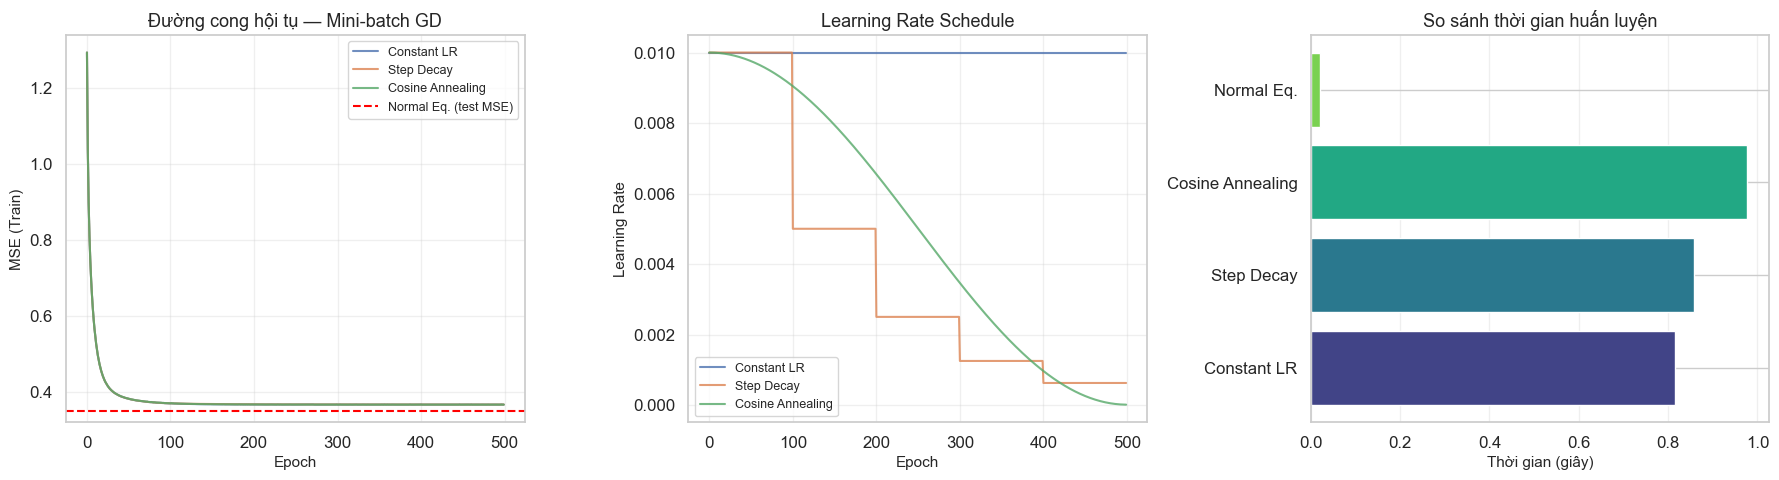

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Convergence curves
ax = axes[0]
for name, model in gd_models.items():
    ax.plot(model.loss_history, label=name, alpha=0.8)
ax.axhline(y=metrics_ne["MSE"], color="red", linestyle="--", label="Normal Eq. (test MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (Train)")
ax.set_title("Đường cong hội tụ — Mini-batch GD")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Learning rate over epochs
ax = axes[1]
for name, model in gd_models.items():
    ax.plot(model.lr_history, label=name, alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Thời gian huấn luyện
ax = axes[2]
names = list(gd_models.keys()) + ["Normal Eq."]
times = [m.fit_time for m in gd_models.values()] + [ne_model.fit_time]
colors = sns.color_palette("viridis", len(names))
ax.barh(names, times, color=colors)
ax.set_xlabel("Thời gian (giây)")
ax.set_title("So sánh thời gian huấn luyện")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

---
## 3. Kiểm tra giả thiết Gauss–Markov

### 3.1. Cơ sở lý thuyết

Theo **định lý Gauss–Markov**, ước lượng OLS là BLUE (Best Linear Unbiased Estimator) khi thỏa các giả thiết:

1. **Tuyến tính**: $\mathbf{y} = \mathbf{X}\mathbf{w} + \boldsymbol{\epsilon}$
2. **Kỳ vọng sai số bằng 0**: $\mathbb{E}[\epsilon_i] = 0$
3. **Phương sai đồng nhất** (Homoscedasticity): $\text{Var}(\epsilon_i) = \sigma^2, \forall i$
4. **Không tương quan**: $\text{Cov}(\epsilon_i, \epsilon_j) = 0, i \neq j$

**Các phương pháp kiểm tra**:
- **Residual plot**: Scatter plot của $\hat{\epsilon}_i$ theo $\hat{y}_i$ — nếu homoscedastic thì phần dư phân bố đều quanh 0
- **QQ-plot**: So sánh phân vị phần dư với phân phối chuẩn — kiểm tra tính chuẩn
- **Kiểm định Breusch–Pagan**: Kiểm tra giả thuyết $H_0: \sigma_i^2 = \sigma^2$ (đồng phương sai)
  - Hồi quy $\hat{\epsilon}_i^2$ theo $\mathbf{X}$
  - Thống kê $LM = nR^2 \sim \chi^2(p)$ 
  - Nếu $p\text{-value} < 0.05$ → bác bỏ $H_0$ → có **heteroscedasticity**

### 3.2. Cài đặt hàm `gauss_markov_diagnostics`

In [8]:
def gauss_markov_diagnostics(y_true, y_pred, X, plot=True):
    """Kiểm tra giả thiết Gauss-Markov.
    
    1. Residual plot: kiểm tra homoscedasticity
    2. QQ-plot: kiểm tra phân phối chuẩn
    3. Breusch-Pagan test: kiểm định thống kê heteroscedasticity
    """
    import statsmodels.stats.diagnostic as smd
    
    residuals = y_true - y_pred
    X_b = _add_bias(X)
    
    # --- Breusch-Pagan test ---
    bp_stat, bp_pvalue, bp_f, bp_f_pvalue = smd.het_breuschpagan(residuals, X_b)
    
    result = {
        "bp_statistic": float(bp_stat),
        "bp_p_value": float(bp_pvalue),
        "bp_f_statistic": float(bp_f),
        "bp_f_p_value": float(bp_f_pvalue),
        "heteroscedastic": bp_pvalue < 0.05,
        "residual_mean": float(residuals.mean()),
        "residual_std": float(residuals.std()),
    }
    
    print("\n=== Gauss–Markov Diagnostics ===")
    print(f"  Residual mean : {result['residual_mean']:.6f}  (nên ≈ 0)")
    print(f"  Residual std  : {result['residual_std']:.6f}")
    print(f"\n  Kiểm định Breusch–Pagan:")
    print(f"    LM statistic : {result['bp_statistic']:.4f}")
    print(f"    p-value      : {result['bp_p_value']:.6f}")
    print(f"    F statistic  : {result['bp_f_statistic']:.4f}")
    print(f"    F p-value    : {result['bp_f_p_value']:.6f}")
    if result["heteroscedastic"]:
        print("    → Phát hiện Heteroscedasticity (p < 0.05)")
        print("    → Cân nhắc sử dụng Weighted Least Squares (WLS)")
    else:
        print("    → Không phát hiện heteroscedasticity (p >= 0.05)")
    
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Residual vs Predicted
        axes[0].scatter(y_pred, residuals, alpha=0.3, s=10, edgecolors="none")
        axes[0].axhline(y=0, color="red", linewidth=1.2, linestyle="--")
        axes[0].set_xlabel("Giá trị dự đoán")
        axes[0].set_ylabel("Phần dư")
        axes[0].set_title("Residuals vs Predicted")
        axes[0].grid(True, alpha=0.3)
        
        # Histogram
        axes[1].hist(residuals, bins=40, edgecolor="white", alpha=0.8, color="steelblue")
        axes[1].set_xlabel("Giá trị phần dư")
        axes[1].set_ylabel("Tần suất")
        axes[1].set_title("Phân phối phần dư")
        axes[1].grid(True, alpha=0.3)
        
        # QQ-plot
        stats.probplot(residuals, dist="norm", plot=axes[2])
        axes[2].set_title("QQ-Plot phần dư")
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return result

### 3.3. Chạy kiểm tra Gauss–Markov cho mô hình Normal Equations


=== Gauss–Markov Diagnostics ===
  Residual mean : -0.000000  (nên ≈ 0)
  Residual std  : 0.605756

  Kiểm định Breusch–Pagan:
    LM statistic : 3633.6865
    p-value      : 0.000000
    F statistic  : 105.3074
    F p-value    : 0.000000
    → Phát hiện Heteroscedasticity (p < 0.05)
    → Cân nhắc sử dụng Weighted Least Squares (WLS)


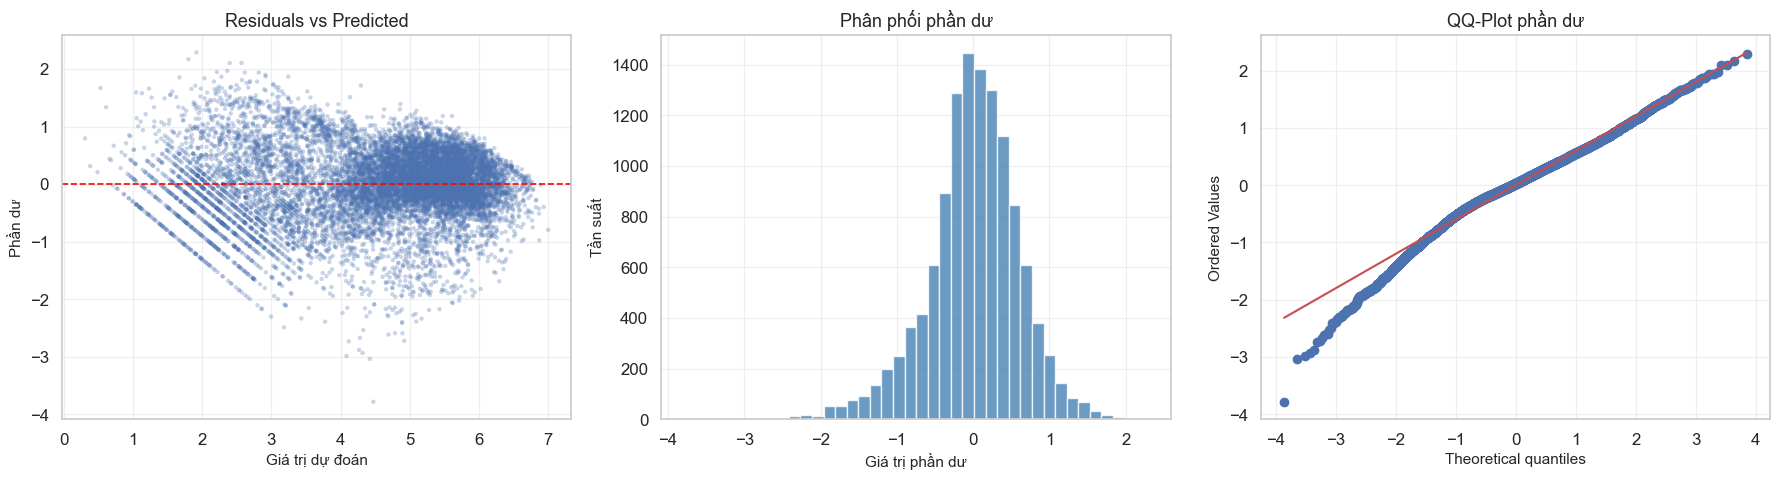

In [9]:
# Chạy diagnostics trên tập train
y_pred_train_ne = ne_model.predict(X_train)
gm_result = gauss_markov_diagnostics(y_train, y_pred_train_ne, X_train, plot=True)

---
## 4. Weighted Least Squares (WLS)

### 4.1. Cơ sở lý thuyết

Khi phát hiện **heteroscedasticity** (phương sai không đồng nhất), OLS không còn là ước lượng hiệu quả nhất. Ta sử dụng **Weighted Least Squares**:

$$\min_\mathbf{w} \sum_{i=1}^N w_i (y_i - \mathbf{x}_i^T \mathbf{w})^2$$

trong đó $w_i > 0$ là trọng số cho mẫu thứ $i$, thường $w_i = 1/\hat{\sigma}_i^2$.

Dạng ma trận: với $\mathbf{W} = \text{diag}(w_1, \ldots, w_N)$:

$$\boxed{\mathbf{w}^* = (\mathbf{X}^T \mathbf{W} \mathbf{X})^{-1} \mathbf{X}^T \mathbf{W} \mathbf{y}}$$

**Trick tính toán**: Đặt $\tilde{\mathbf{X}} = \sqrt{\mathbf{W}}\mathbf{X}$, $\tilde{\mathbf{y}} = \sqrt{\mathbf{W}}\mathbf{y}$, thì WLS trở thành OLS trên dữ liệu đã biến đổi:

$$\mathbf{w}^* = (\tilde{\mathbf{X}}^T \tilde{\mathbf{X}})^{-1} \tilde{\mathbf{X}}^T \tilde{\mathbf{y}}$$

### 4.2. Cài đặt class `WeightedLeastSquares`

In [10]:
class WeightedLeastSquares:
    """Weighted Least Squares cho dữ liệu heteroscedastic.
    
    Tối thiểu hóa sum_i w_i * (y_i - x_i^T β)^2
    Nghiệm dạng đóng: β = (X^T W X)^{-1} X^T W y
    """
    
    def __init__(self):
        self.w = None
        self.fit_time = 0.0
    
    def fit(self, X, y, weights=None, **kwargs):
        """Fit WLS. Nếu weights=None thì fallback về OLS."""
        t0 = time.perf_counter()
        X_b = _add_bias(X)
        
        if weights is None:
            weights = np.ones(len(y))
        
        # Trick: sqrt(W) X, sqrt(W) y → OLS trên dữ liệu đã biến đổi
        sqrt_w = np.sqrt(weights)
        X_w = X_b * sqrt_w[:, np.newaxis]
        y_w = y * sqrt_w
        
        XtX = X_w.T @ X_w
        Xty = X_w.T @ y_w
        self.w = np.linalg.solve(XtX, Xty)
        self.fit_time = time.perf_counter() - t0
        return self
    
    def predict(self, X):
        X_b = _add_bias(X)
        return X_b @ self.w
    
    @property
    def coefficients(self):
        return self.w[1:] if self.w is not None else np.array([])
    
    @property
    def intercept(self):
        return float(self.w[0]) if self.w is not None else 0.0

### 4.3. Huấn luyện WLS và so sánh với OLS

In [11]:
# Huấn luyện WLS với trọng số từ preprocessing
wls_model = WeightedLeastSquares()
wls_model.fit(X_train, y_train, weights=weights_train)

print(f"Thời gian huấn luyện WLS: {wls_model.fit_time:.6f} giây")

# Đánh giá
y_pred_wls = wls_model.predict(X_test)
metrics_wls = compute_all_metrics(y_test, y_pred_wls)
print_metrics(metrics_wls, "Weighted Least Squares — Test Set")

# So sánh OLS vs WLS
print("\n--- So sánh OLS (Normal Eq.) vs WLS ---")
comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "OLS (Normal Eq.)": [metrics_ne[k] for k in ["MSE", "RMSE", "MAE", "R²"]],
    "WLS": [metrics_wls[k] for k in ["MSE", "RMSE", "MAE", "R²"]],
})
comparison["Δ (WLS - OLS)"] = comparison["WLS"] - comparison["OLS (Normal Eq.)"]
print(comparison.to_string(index=False))

Thời gian huấn luyện WLS: 0.013245 giây

  Weighted Least Squares — Test Set
     MSE: 0.369868
    RMSE: 0.608168
     MAE: 0.429387
      R²: 0.814841


--- So sánh OLS (Normal Eq.) vs WLS ---
Metric  OLS (Normal Eq.)      WLS  Δ (WLS - OLS)
   MSE          0.349341 0.369868       0.020526
  RMSE          0.591051 0.608168       0.017117
   MAE          0.447499 0.429387      -0.018112
    R²          0.825117 0.814841      -0.010276


---
## 5. Biểu đồ Predicted vs Actual và so sánh tổng hợp

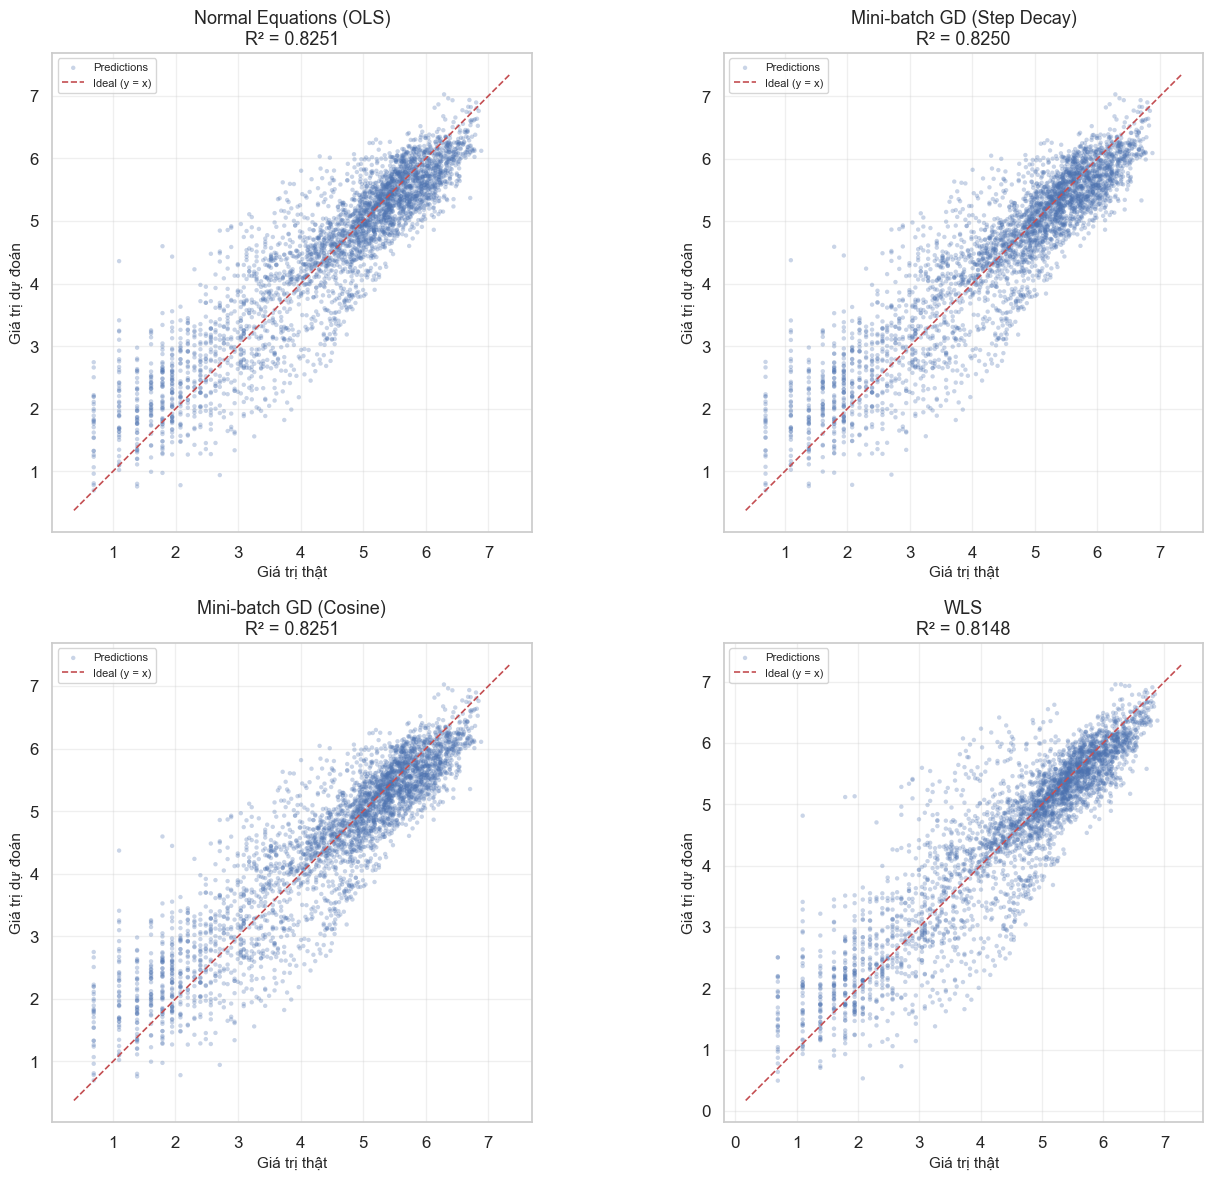

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

all_models = {
    "Normal Equations (OLS)": (ne_model, metrics_ne),
    "Mini-batch GD (Step Decay)": (gd_models["Step Decay"], gd_metrics["Step Decay"]),
    "Mini-batch GD (Cosine)": (gd_models["Cosine Annealing"], gd_metrics["Cosine Annealing"]),
    "WLS": (wls_model, metrics_wls),
}

for idx, (name, (model, metrics)) in enumerate(all_models.items()):
    ax = axes[idx // 2][idx % 2]
    y_pred = model.predict(X_test)
    
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, edgecolors="none", label="Predictions")
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin],
            "r--", linewidth=1.2, label="Ideal (y = x)")
    ax.set_xlabel("Giá trị thật")
    ax.set_ylabel("Giá trị dự đoán")
    ax.set_title(f"{name}\nR² = {metrics['R²']:.4f}")
    ax.legend(fontsize=8)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Bảng tổng hợp kết quả

In [ ]:
# Tổng hợp
results_data = []
for name, (model, metrics) in all_models.items():
    results_data.append({
        "Model": name,
        "MSE": metrics["MSE"],
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "R²": metrics["R²"],
        "Train Time (s)": model.fit_time,
    })

results_df = pd.DataFrame(results_data)
print("\n" + "="*80)
print("  BẢNG TỔNG HỢP KẾT QUẢ — Linear Regression (Section 1.1)")
print("="*80)
print(results_df.to_string(index=False, float_format="%.6f"))
print("="*80)

# Lưu kết quả để sử dụng cho Phase 6 (Evaluation)
results_section_1_1 = results_df.copy()
print("\n Kết quả đã lưu vào biến `results_section_1_1`")


  BẢNG TỔNG HỢP KẾT QUẢ — Linear Regression (Section 1.1)
                     Model      MSE     RMSE      MAE       R²  Train Time (s)
    Normal Equations (OLS) 0.349341 0.591051 0.447499 0.825117        0.020583
Mini-batch GD (Step Decay) 0.349637 0.591301 0.447170 0.824969        0.857450
    Mini-batch GD (Cosine) 0.349384 0.591087 0.447226 0.825096        0.977620
                       WLS 0.369868 0.608168 0.429387 0.814841        0.013245

✓ Kết quả đã lưu vào biến `results_section_1_1`
